In [1]:
from bcb import sgs
import pandas as pd

ipca = sgs.get(433)
ibc_br = sgs.get(4380)

In [2]:
#selic1 = sgs.get(432, start='1999-01-15', end='2009-01-14')
#selic2 = sgs.get(432, start='2009-01-15', end='2019-01-14')
#selic3 = sgs.get(432, start='2019-01-15')
#selic = pd.concat([selic1,selic2,selic3])

In [3]:
selic = pd.read_csv('selic.csv')

<Axes: xlabel='Date'>

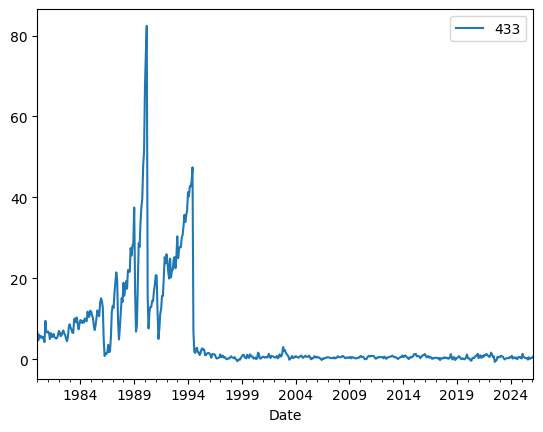

In [4]:
ipca.plot.line()

<Axes: >

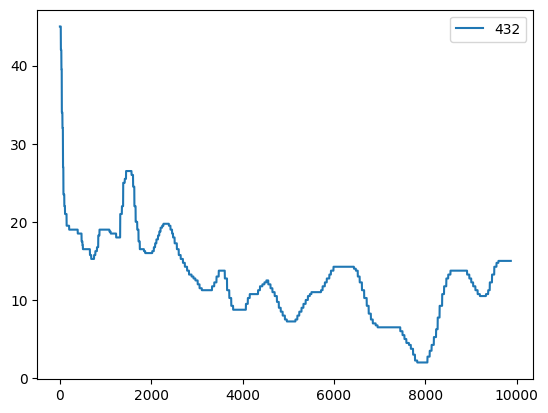

In [5]:
selic.plot.line()

<Axes: xlabel='Date'>

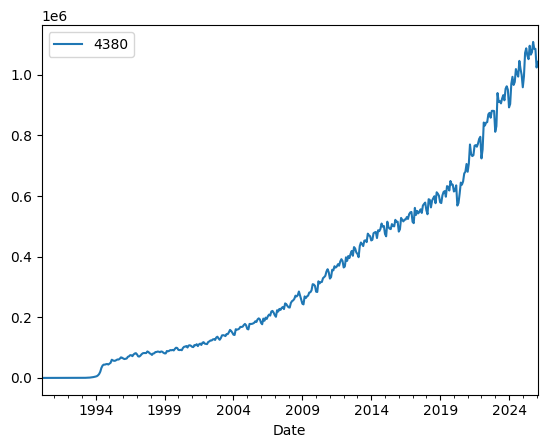

In [6]:
ibc_br.plot.line()

vamos deixar os 3 para começar em janeiro de 10/05/2004 porque foi quando a ANP começou a disponibilizar os preços domésticos da gasolina até 30/01/2026 que é a última data disponível para isso

In [7]:
# retirando multiindex
ipca = ipca.reset_index()
ibc_br = ibc_br.reset_index()

In [8]:
# transformando para datetime
selic['Date'] = pd.to_datetime(selic['Date'])
ipca['Date'] = pd.to_datetime(ipca['Date'])
ibc_br['Date'] = pd.to_datetime(ibc_br['Date'])

In [9]:
# agrupando por mẽs
ipca = (
    ipca
    .rename(columns={'433': 'ipca'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2004-05-10" and Date <= "2026-01-01"')
)
selic = (
    selic
    .rename(columns={'432': 'selic'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2005-05-31" and Date <= "2026-01-01"')
)
ibc_br = (
    ibc_br
    .rename(columns={'4380': 'ibc_br'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2004-05-10" and Date <= "2026-01-01"')
)

In [10]:
ipca12 = ipca.rolling(12).sum().dropna() # deixamos o ipca pegando a soma da variação percentual dos últimos 12 meses
ibc_br12 = ibc_br.pct_change(12) * 100 # e aqui a variação anual dos últimos 12 meses
ibc_br12 = ibc_br12.dropna()
ipca12 = ipca12.query('Date >= "2005-05-31" and Date <= "2026-01-01"')
display(ipca12, ibc_br12)

,ipca
Date,
2005-05-31,7.77
2005-06-30,7.04
2005-07-31,6.38
2005-08-31,5.86
2005-09-30,5.88
...,...
2025-08-31,5.02
2025-09-30,5.06
2025-10-31,4.59


,ibc_br
Date,
2005-05-31,11.252991
2005-06-30,10.420683
2005-07-31,7.999696
2005-08-31,11.093274
2005-09-30,9.176741
...,...
2025-08-31,6.189054
2025-09-30,8.136850
2025-10-31,5.980075


In [11]:
selic

,selic
Date,
2005-05-31,19.604839
2005-06-30,19.750000
2005-07-31,19.750000
2005-08-31,19.750000
2005-09-30,19.616667
...,...
2025-08-31,15.000000
2025-09-30,15.000000
2025-10-31,15.000000


In [12]:
df = (
    selic
    .merge(ipca12, on='Date')
    .merge(ibc_br12, on='Date')
)
df['selic'] = df['selic'].round(2)
df['ibc_br'] = df['ibc_br'].round(2)
df

,selic,ipca,ibc_br
Date,,,
2005-05-31,19.60,7.77,11.25
2005-06-30,19.75,7.04,10.42
2005-07-31,19.75,6.38,8.00
2005-08-31,19.75,5.86,11.09
2005-09-30,19.62,5.88,9.18
...,...,...,...
2025-08-31,15.00,5.02,6.19
2025-09-30,15.00,5.06,8.14
2025-10-31,15.00,4.59,5.98


agora juntando com os preços da gasolina pegando dos dados da anp

In [13]:
import requests as re
url = 'https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis'
response = re.get(url)

In [15]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')
links = soup.find_all('a', href=lambda h: h and 'ca/ca' in h)
links

[<a class="internal-link" data-tippreview-enabled="false" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2025-02.zip" target="_blank" title="">2º semestre de 2025</a>,
 <a class="internal-link" data-tippreview-enabled="true" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2025-01.zip" target="_blank" title="">1º semestre de 2025</a>,
 <a class="internal-link" data-tippreview-enabled="true" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2024-02.zip" target="_blank" title="">2º semestre de 2024</a>,
 <a class="internal-link" data-tippreview-enabled="false" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2

In [27]:
import os

if not os.path.exists('gas_prices'):
    os.mkdir('gas_prices')

# baixando arquivos com preços da gasolina
for arquivo in links:
    url = arquivo.attrs['href']
    file_name = url.split('/')[-1]

    output_path = f'gas_prices/{file_name}'
    if os.path.exists(output_path):
        continue

    print(f"Arquivo atual: {file_name}")
    with re.get(url, stream=True) as response:
        response.raise_for_status()

        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

print('Download concluído')

Arquivo atual: ca-2017-02.csv
Arquivo atual: ca-2017-01.csv
Arquivo atual: ca-2016-02.csv
Arquivo atual: ca-2016-01.csv
Arquivo atual: ca-2015-02.csv
Arquivo atual: ca-2015-01.csv


KeyboardInterrupt: 